In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Load data
pc_data = pd.read_csv('../PhysiCell/results/mechanics_movement/cell_position_time.csv')

output_folder = '../Biodynamo/unit_test_mechanics_friction_single/results/'
bd_data = pd.read_csv(output_folder + 'positions.csv', index_col=0, header=None, sep='\t|,', engine='python').rename(columns={1: "x", 2: "y", 3: "z"})
bd_data['dx'] = abs(bd_data['x'] - bd_data['x'].shift(1))
bd_data.fillna({"dx": 0}, inplace=True)
bd_data['timestep'] = np.arange(0, 10, 0.1)
bd_data['dt'] = 0.1
bd_data['velocity'] = bd_data['dx'] / bd_data['dt']

output_folder = '../Chaste/unit_test_mechanics_friction/results/'
ch_data = pd.read_csv(output_folder + 'node_locations.dat', header=None, names=["timestep", "x", "y"], sep='\t| ', index_col=None, engine='python')
ch_data['dx'] = abs(ch_data["x"] - ch_data["x"].shift(1))
ch_data.fillna({"dx": 0}, inplace=True)
ch_data['timestep'] = np.arange(0, 10.01, 0.1)
ch_data['dt'] = 0.1
ch_data['velocity'] = ch_data['dx'] / ch_data['dt']

output_folder = "../Tisim/unit_test_mechanics_friction/"
# ts_data = pd.read_csv(output_folder + 'mechanical friction.csv', header=0, sep='\t|,', engine='python', names=["dt", "velocity"])
ts_data = pd.read_csv(output_folder + 'mechanical friction_offset.csv', header=0, sep='\t|,', engine='python', names=["dt", "velocity"])

# Set up colorblind-friendly colors and linestyles
colors = {
    'PhysiCell': '#4daf4a',   # Green
    'BioDynaMo': '#ff7f00',   # Orange (changed from red)
    'Chaste': '#377eb8',      # Blue
    'TiSim': '#984ea3'        # Purple
}
linestyles = {
    'PhysiCell': 'dotted',
    'BioDynaMo': 'dotted',
    'Chaste': 'dotted',
    'TiSim': 'dotted'
}
labels = {
    'PhysiCell': 'PhysiCell',
    'BioDynaMo': 'BioDynaMo',
    'Chaste': 'Chaste',
    'TiSim': 'TiSim'
}
# Update font and axes settings for better readability
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Helvetica', 'Arial', 'sans-serif'],
    'font.size': 8,  # Increased from 7
    'axes.labelsize': 9,  # Increased from 8
    'axes.titlesize': 9,  # Increased from 8
    'xtick.labelsize': 8,  # Increased from 7
    'ytick.labelsize': 8,  # Increased from 7
    'legend.fontsize': 8,  # Increased from 7
    'lines.linewidth': 1.8,  # Increased from 1.2
    'axes.linewidth': 0.8,  # Increased from 0.5
    'xtick.major.width': 0.8,  # Increased from 0.5
    'ytick.major.width': 0.8,  # Increased from 0.5
    'xtick.major.size': 3,  # Increased from 2
    'ytick.major.size': 3,  # Increased from 2
    'figure.dpi': 400
})


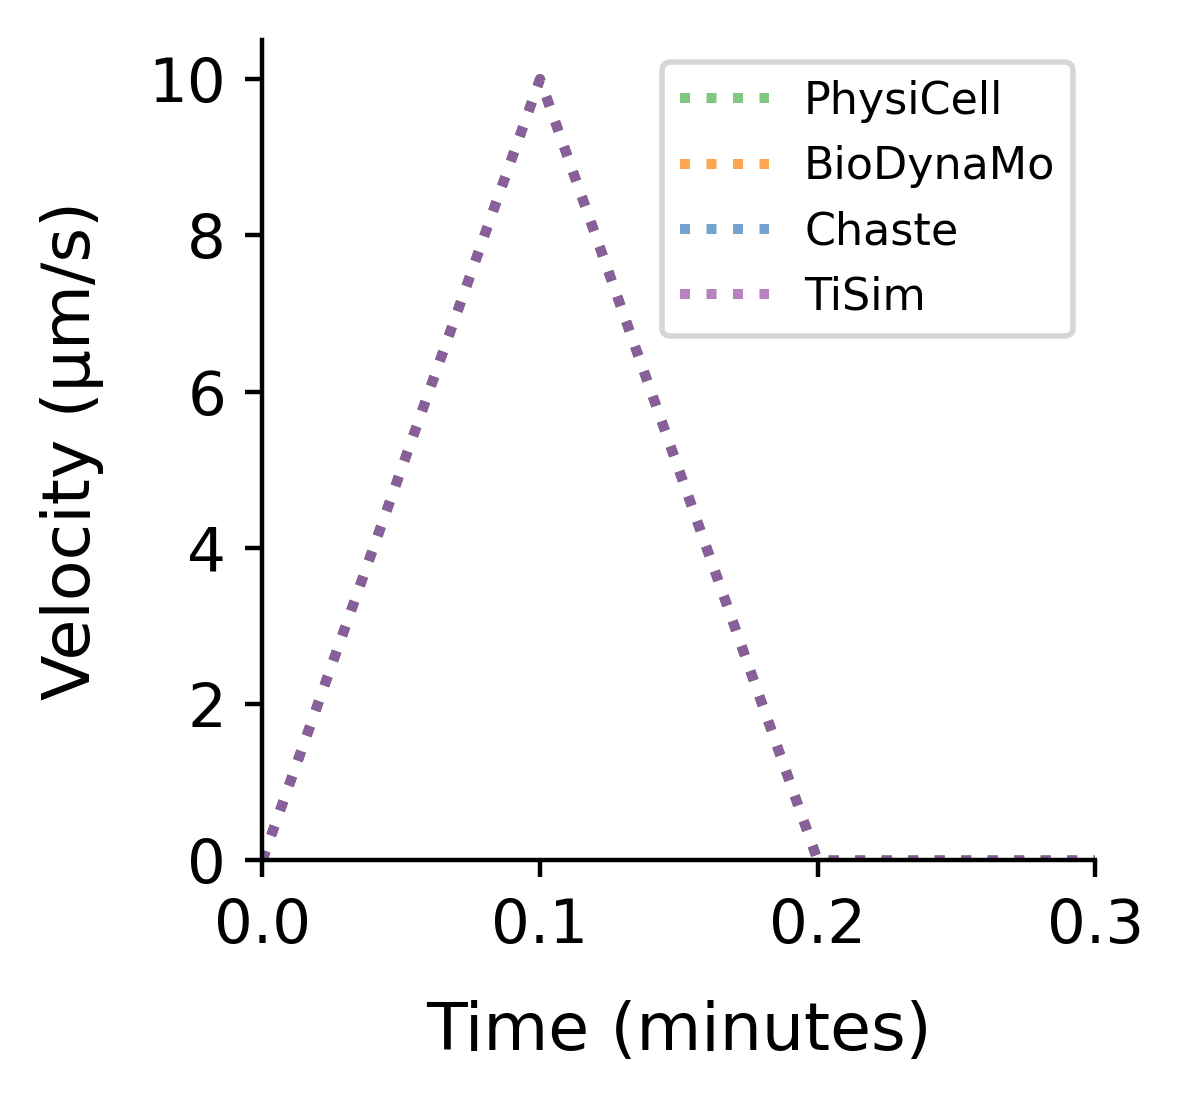

In [27]:
# Create square figure for zoomed plot (0–0.25 min)
fig, ax = plt.subplots(figsize=(3, 2.8))

# Plot each simulator (restrict to 0–0.25 min)
# mask_pc = (pc_data['dt'] >= 0) & (pc_data['dt'] <= 0.3)
# mask_bd = (bd_data['timestep'] >= 0) & (bd_data['timestep'] <= 0.3)
# mask_ch = (ch_data['timestep'] >= 0) & (ch_data['timestep'] <= 0.3)
# mask_ts = (ts_data['dt'] >= 0) & (ts_data['dt'] <= 0.3)

ax.plot(pc_data['dt'], pc_data['mvx'],
        color=colors['PhysiCell'], label=labels['PhysiCell'],
        linestyle=linestyles['PhysiCell'], alpha=0.7, linewidth=1.8)
ax.plot(bd_data['timestep'], bd_data['velocity'],
        color=colors['BioDynaMo'], label=labels['BioDynaMo'],
        linestyle=linestyles['BioDynaMo'], alpha=0.7, linewidth=1.8)
ax.plot(ch_data['timestep'], ch_data['velocity'],
        color=colors['Chaste'], label=labels['Chaste'],
        linestyle=linestyles['Chaste'], alpha=0.7, linewidth=1.8)
ax.plot(ts_data['dt'], ts_data['velocity'],
        color=colors['TiSim'], label=labels['TiSim'],
        linestyle=linestyles['TiSim'], alpha=0.7, linewidth=1.8)

# Axis labels and limits
ax.set_ylabel("Velocity (μm/s)", labelpad=8, fontsize=12)
ax.set_xlabel("Time (minutes)", labelpad=8, fontsize=12)
ax.set_xlim(0, 0.3)
ax.set_ylim(bottom=0)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend
ax.legend(loc='best', fontsize=8)

# Remove grid
ax.grid(False)

# Set tick label size
ax.tick_params(axis='both', which='major', labelsize=11)

plt.tight_layout()

# Save in vector and raster formats
# save_dir = "./ResultAnalysis/plots/mechanics_friction_plots"
# os.makedirs(save_dir, exist_ok=True)
# plt.savefig(os.path.join(save_dir, "mechanics_friction_zoomed.pdf"),
#             format='pdf', bbox_inches='tight', pad_inches=0.1)
# plt.savefig(os.path.join(save_dir, "mechanics_friction_zoomed.svg"),
#             format='svg', bbox_inches='tight', pad_inches=0.1)
# plt.savefig(os.path.join(save_dir, "mechanics_friction_zoomed.png"),
#             dpi=600, bbox_inches='tight', pad_inches=0.1, format='png')
# plt.close(fig)



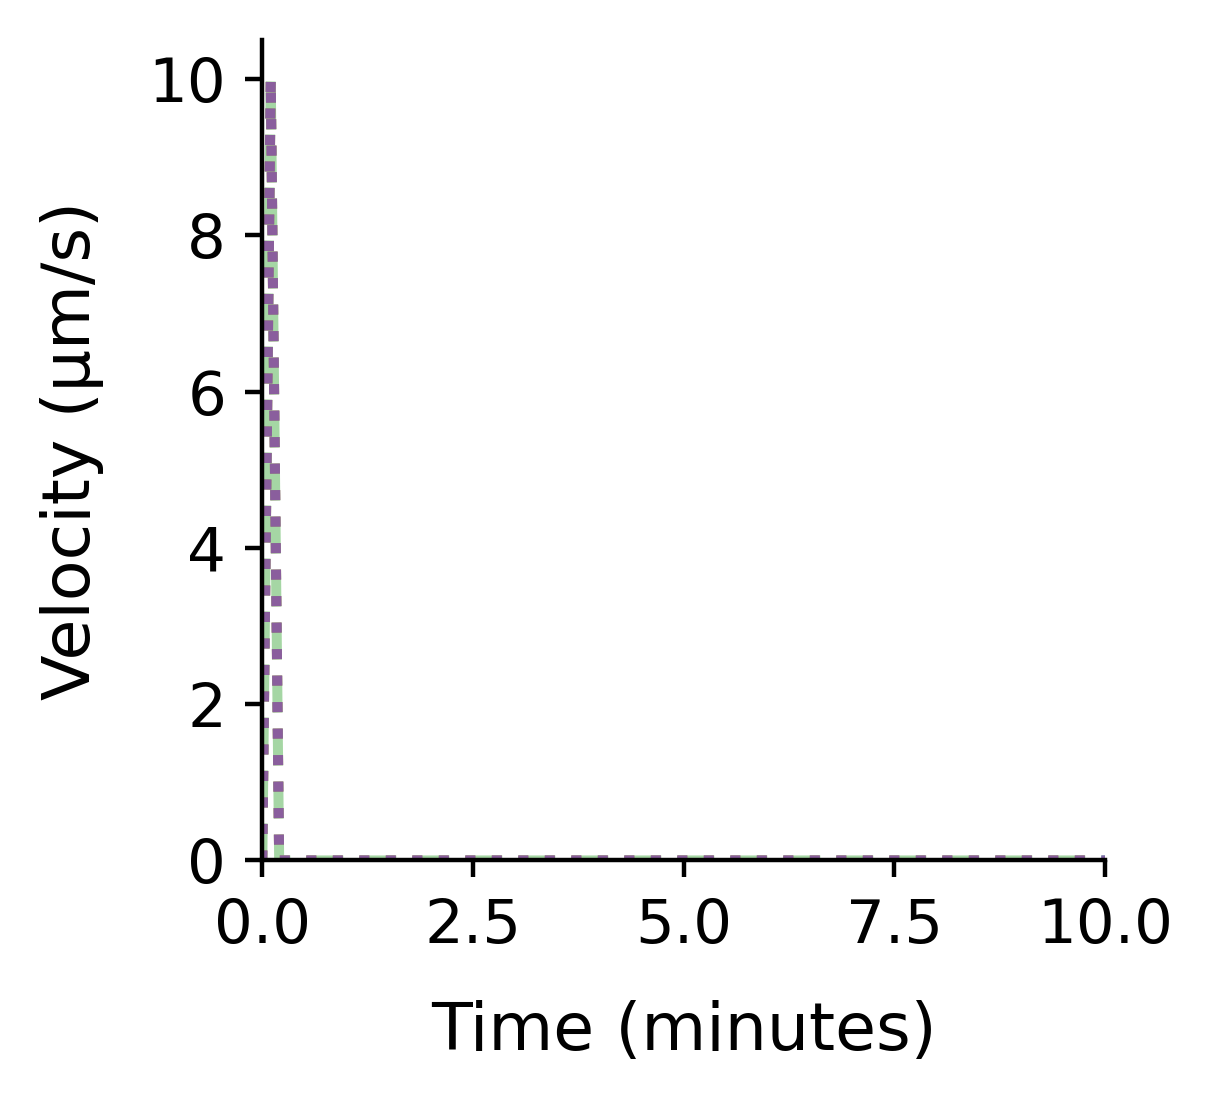

In [14]:
# --- FULL TIME COURSE PLOT (0–10 min) ---

fig_full, ax_full = plt.subplots(figsize=(3, 2.8))

# Plot each simulator (full time course)
ax_full.plot(pc_data['dt'], pc_data['mvx'],
             color=colors['PhysiCell'],
             linestyle=linestyles['PhysiCell'], alpha=0.5, linewidth=1.8)
ax_full.plot(bd_data['timestep'], bd_data['velocity'],
             color=colors['BioDynaMo'],
             linestyle=linestyles['BioDynaMo'], alpha=0.7, linewidth=1.8)
ax_full.plot(ch_data['timestep'], ch_data['velocity'],
             color=colors['Chaste'],
             linestyle=linestyles['Chaste'], alpha=0.7, linewidth=1.8)
ax_full.plot(ts_data['dt'], ts_data['velocity'],
             color=colors['TiSim'],
             linestyle=linestyles['TiSim'], alpha=0.7, linewidth=1.8)

ax_full.set_ylabel("Velocity (μm/s)", labelpad=8, fontsize=12)
ax_full.set_xlabel("Time (minutes)", labelpad=8, fontsize=12)
ax_full.set_xlim(0, 10)
ax_full.set_ylim(bottom=0)

ax_full.spines['top'].set_visible(False)
ax_full.spines['right'].set_visible(False)
ax_full.grid(False)
ax_full.tick_params(axis='both', which='major', labelsize=11)

plt.tight_layout()

# plt.savefig(os.path.join(save_dir, "mechanics_friction_full.pdf"),
#             format='pdf', bbox_inches='tight', pad_inches=0.1)
# plt.savefig(os.path.join(save_dir, "mechanics_friction_full.svg"),
#             format='svg', bbox_inches='tight', pad_inches=0.1)
# plt.savefig(os.path.join(save_dir, "mechanics_friction_full.png"),
#             dpi=600, bbox_inches='tight', pad_inches=0.1, format='png')
# plt.close(fig_full)



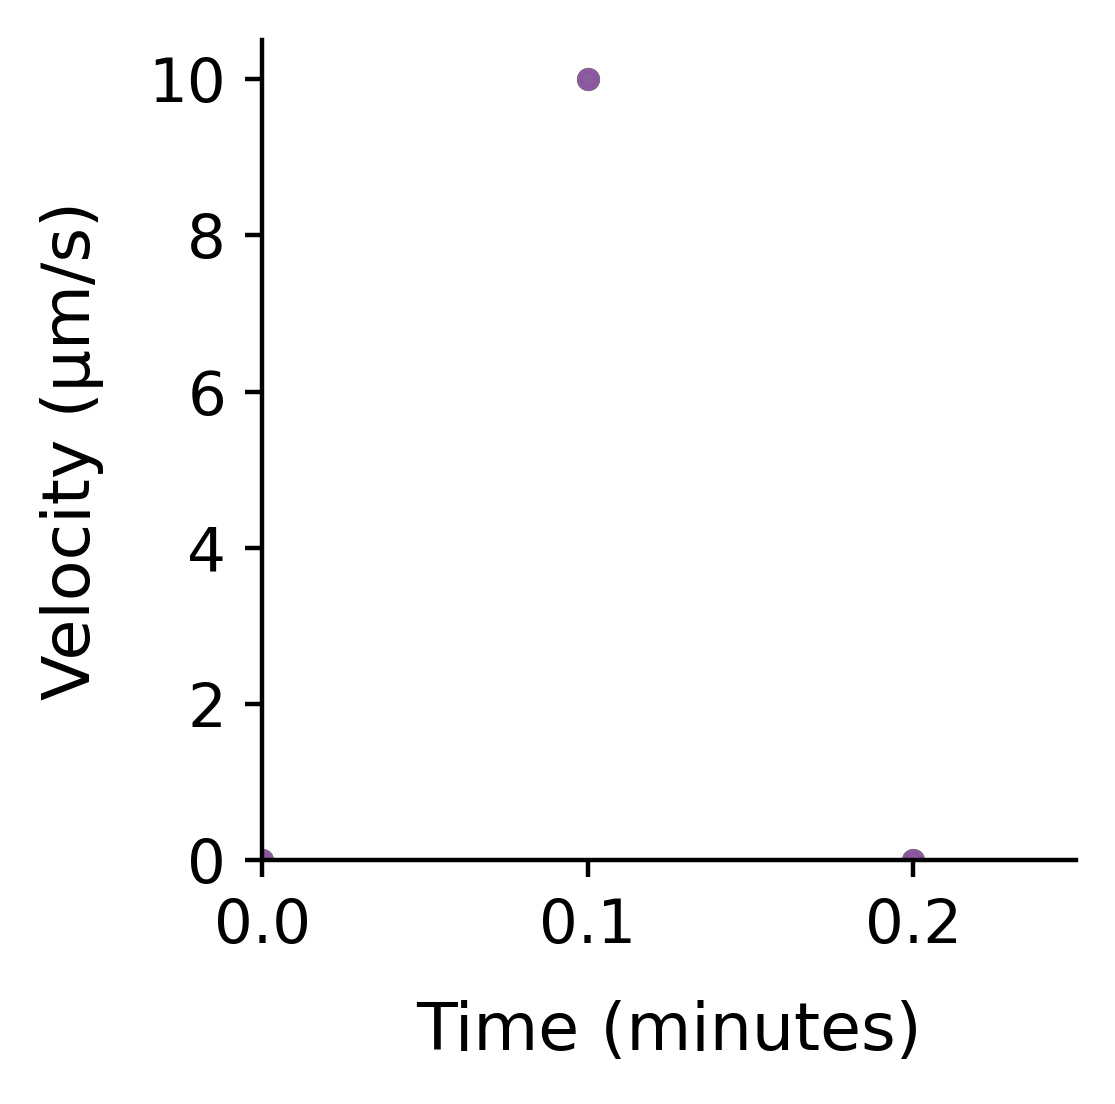

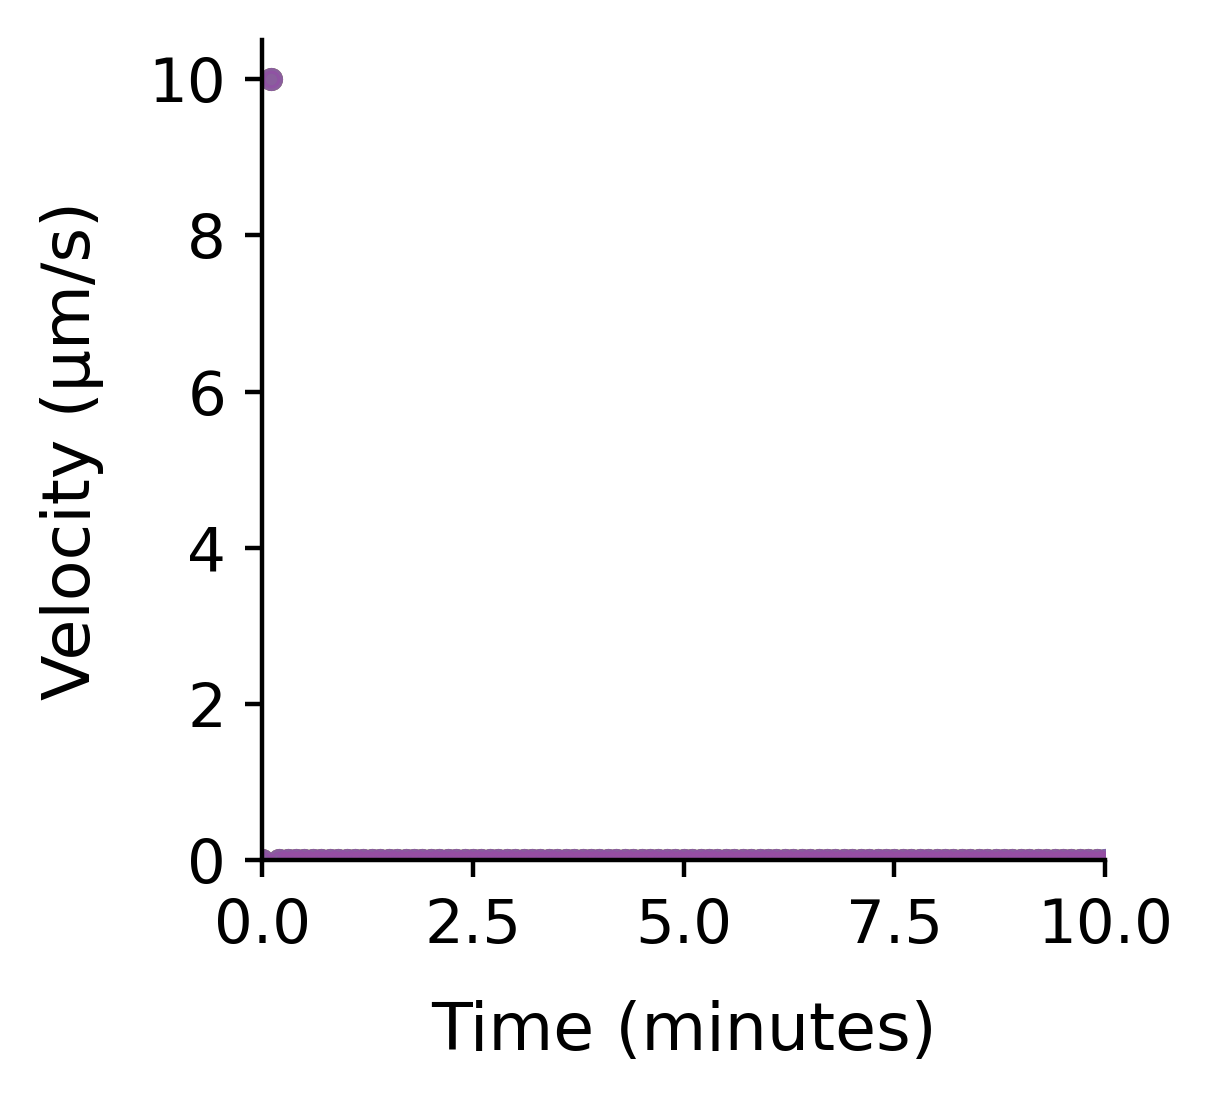

In [ ]:
# --- SCATTERPLOT VERSION: ZOOMED (0–0.25 min) ---
fig_scatter, ax_scatter = plt.subplots(figsize=(3, 2.8))
ax_scatter.scatter(pc_data['dt'], pc_data['mvx'][mask_pc],
                   color=colors['PhysiCell'], alpha=0.7, s=10, label='PhysiCell')
ax_scatter.scatter(bd_data['timestep'][mask_bd], bd_data['velocity'][mask_bd],
                   color=colors['BioDynaMo'], alpha=0.7, s=10, label='BioDynaMo')
ax_scatter.scatter(ch_data['timestep'][mask_ch], ch_data['velocity'][mask_ch],
                   color=colors['Chaste'], alpha=0.7, s=10, label='Chaste')
ax_scatter.scatter(ts_data['dt'][mask_ts], ts_data['velocity'][mask_ts],
                   color=colors['TiSim'], alpha=0.7, s=10, label='TiSim')
ax_scatter.set_ylabel("Velocity (μm/s)", labelpad=8, fontsize=12)
ax_scatter.set_xlabel("Time (minutes)", labelpad=8, fontsize=12)
ax_scatter.set_xlim(0, 0.25)
ax_scatter.set_ylim(bottom=0)
ax_scatter.spines['top'].set_visible(False)
ax_scatter.spines['right'].set_visible(False)
ax_scatter.grid(False)
ax_scatter.tick_params(axis='both', which='major', labelsize=11)
plt.tight_layout()
# plt.savefig(os.path.join(save_dir, "mechanics_friction_zoomed_scatter.pdf"),
#             format='pdf', bbox_inches='tight', pad_inches=0.1)
# plt.savefig(os.path.join(save_dir, "mechanics_friction_zoomed_scatter.svg"),
#             format='svg', bbox_inches='tight', pad_inches=0.1)
# plt.savefig(os.path.join(save_dir, "mechanics_friction_zoomed_scatter.png"),
#             dpi=600, bbox_inches='tight', pad_inches=0.1, format='png')
# plt.close(fig_scatter)

# --- SCATTERPLOT VERSION: FULL TIME COURSE (0–10 min) ---
fig_full_scatter, ax_full_scatter = plt.subplots(figsize=(3, 2.8))
ax_full_scatter.scatter(pc_data['dt'], pc_data['mvx'],
                       color=colors['PhysiCell'], alpha=0.5, s=10, label='PhysiCell')
ax_full_scatter.scatter(bd_data['timestep'], bd_data['velocity'],
                       color=colors['BioDynaMo'], alpha=0.7, s=10, label='BioDynaMo')
ax_full_scatter.scatter(ch_data['timestep'], ch_data['velocity'],
                       color=colors['Chaste'], alpha=0.7, s=10, label='Chaste')
ax_full_scatter.scatter(ts_data['dt'], ts_data['velocity'],
                       color=colors['TiSim'], alpha=0.7, s=10, label='TiSim')
ax_full_scatter.set_ylabel("Velocity (μm/s)", labelpad=8, fontsize=12)
ax_full_scatter.set_xlabel("Time (minutes)", labelpad=8, fontsize=12)
ax_full_scatter.set_xlim(0, 10)
ax_full_scatter.set_ylim(bottom=0)
ax_full_scatter.spines['top'].set_visible(False)
ax_full_scatter.spines['right'].set_visible(False)
ax_full_scatter.grid(False)
ax_full_scatter.tick_params(axis='both', which='major', labelsize=11)
plt.tight_layout()
# plt.savefig(os.path.join(save_dir, "mechanics_friction_full_scatter.pdf"),
#             format='pdf', bbox_inches='tight', pad_inches=0.1)
# plt.savefig(os.path.join(save_dir, "mechanics_friction_full_scatter.svg"),
#             format='svg', bbox_inches='tight', pad_inches=0.1)
# plt.savefig(os.path.join(save_dir, "mechanics_friction_full_scatter.png"),
#             dpi=600, bbox_inches='tight', pad_inches=0.1, format='png')
# plt.close(fig_full_scatter)
